**Handling Outliers in data**

1. Handling using Z-Score  --> Used on normally distributed data<br>
   --> 2 techniques <br>a. Trimming<br>
                    b. Capping

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.sample(5)

,cgpa,placement_exam_marks,placed
459,6.62,79.0,1
953,6.91,44.0,0
807,7.16,19.0,1
824,7.48,27.0,1
484,5.81,18.0,0


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.f

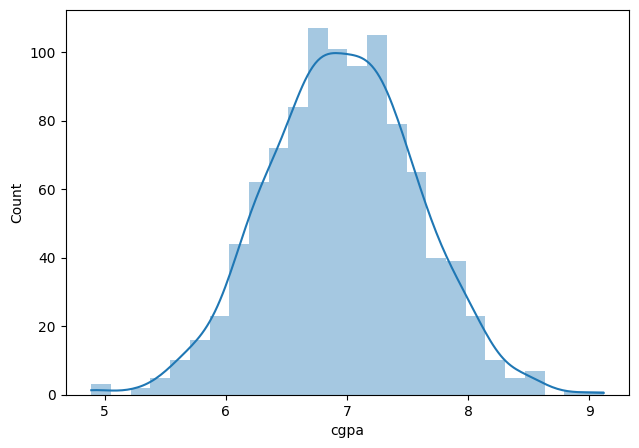

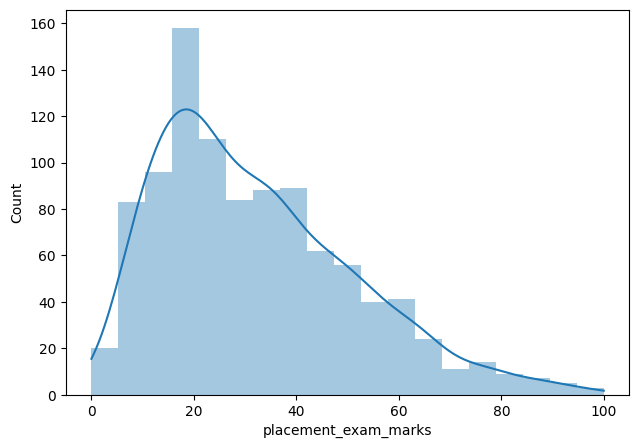

In [4]:
plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['cgpa'], kde=True, edgecolor=None, alpha=0.4)

plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['placement_exam_marks'], kde=True, edgecolor=None, alpha=0.4)

plt.show()

In [5]:
print("Mean of cgpa:", df['cgpa'].mean())
print("Standard deviation of cgpa:", df['cgpa'].std())
print("Min of cgpa:", df['cgpa'].min())
print("Max of cgpa:", df['cgpa'].max())

Mean of cgpa: 6.96124
Standard deviation of cgpa: 0.6158978751323896
Min of cgpa: 4.89
Max of cgpa: 9.12


In [6]:
#Finding the boundary value
print("Higher limit:", df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lower limit:", df['cgpa'].mean() - 3*df['cgpa'].std())

Higher limit: 8.808933625397168
Lower limit: 5.113546374602832


In [7]:
# Finding the outliers
df[(df['cgpa'] > 8.08) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
34,8.15,9.0,0
37,8.51,9.0,1
49,8.23,28.0,1
54,8.42,36.0,1
55,8.12,15.0,0
76,8.35,12.0,0
78,8.20,12.0,0
98,8.12,76.0,0
131,8.19,19.0,1
139,8.09,5.0,1


In [8]:
df.shape

(1000, 3)

**Trimming**

In [10]:
new_df = df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


**Approach 2 - Calculating Z-Score**

In [11]:
#calculate the z score

df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std()

In [12]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [13]:
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [14]:
#Trimming

new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

In [15]:
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


**Capping**

In [16]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [19]:
upper_limit, lower_limit

(np.float64(8.808933625397168), np.float64(5.113546374602832))

In [20]:
df['cgpa'] = np.where(
    df['cgpa'] > upper_limit,
    upper_limit,
    np.where(
        df['cgpa'] < lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [21]:
df.shape

(1000, 4)

In [23]:
df.sample(5)

,cgpa,placement_exam_marks,placed,cgpa_zscore
833,7.29,23.0,1,0.533790
576,6.12,8.0,1,-1.365876
205,6.99,47.0,1,0.046696
353,6.82,28.0,1,-0.229324
636,6.39,43.0,1,-0.927491


In [22]:
df.describe()

,cgpa,placement_exam_marks,placed,cgpa_zscore
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,6.961499,32.225000,0.489000,-1.465494e-16
std,0.612688,19.130822,0.500129,1.000000e+00
min,5.113546,0.000000,0.000000,-3.362960e+00
25%,6.550000,17.000000,0.000000,-6.677081e-01
50%,6.960000,28.000000,0.000000,-2.013321e-03
75%,7.370000,44.000000,1.000000,6.636815e-01
max,8.808934,100.000000,1.000000,3.505062e+00
